In [1]:
#pip install pandas scikit-learn matplotlib seaborn

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("spam.csv", encoding='latin-1')[['v1', 'v2']]
df.columns = ['Label', 'Message']
df['Label'] = df['Label'].map({'ham': 0, 'spam': 1})

print(df.head())

   Label                                            Message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [3]:
X = df['Message']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [5]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

y_pred = nb_model.predict(X_test_vec)

Accuracy: 98.39%


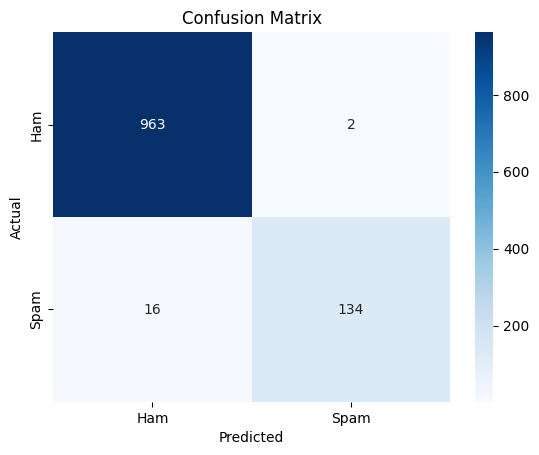

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.89      0.94       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [6]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred))

In [7]:
new_messages = ["Congratulations! You've won a free ticket to Bahamas. Call now!",
                "Hey, are we still meeting for lunch today?",
                "You have been selected for a $1000 gift card. Click here to claim.",
                "Don't forget to submit your assignment by tonight."]

new_vec = vectorizer.transform(new_messages)
predictions = nb_model.predict(new_vec)

for msg, pred in zip(new_messages, predictions):
    label = "Spam" if pred == 1 else "Ham"
    print(f"Message: '{msg}' => Prediction: {label}")

Message: 'Congratulations! You've won a free ticket to Bahamas. Call now!' => Prediction: Spam
Message: 'Hey, are we still meeting for lunch today?' => Prediction: Ham
Message: 'You have been selected for a $1000 gift card. Click here to claim.' => Prediction: Spam
Message: 'Don't forget to submit your assignment by tonight.' => Prediction: Ham
